Loading parquet dataset from ./data/validation-*.parquet...

Loading Standard ViT (Small)...

Starting Automated ToMe Sweep


Evaluating r=32: 100%|██████████| 782/782 [00:53<00:00, 14.53it/s]



Sweep Complete! Final Data Table:
r=0  | Accuracy: 74.63% | Latency: 79.67 ms
r=4  | Accuracy: 74.32% | Latency: 78.17 ms
r=8  | Accuracy: 73.48% | Latency: 72.64 ms
r=16 | Accuracy: 68.25% | Latency: 47.13 ms
r=24 | Accuracy: 26.52% | Latency: 35.59 ms
r=32 | Accuracy:  3.49% | Latency: 26.13 ms

[Success] Pareto curve saved directly to 'tome_pareto_curve.png'!


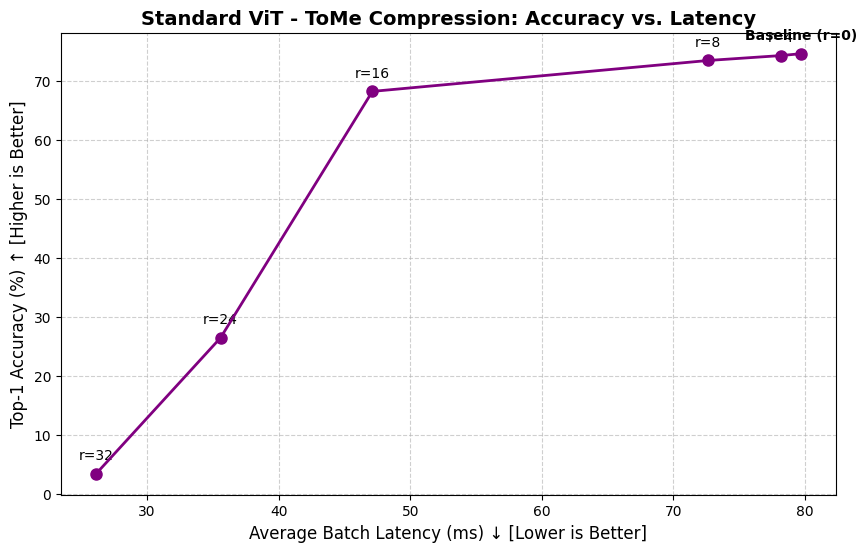

In [3]:
import torch
import timm
import tome
import time
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

# --- Configuration ---
DATA_FILES = "./data/validation-*.parquet" 
BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Added 0 to capture the true baseline performance automatically!
R_VALUES_TO_TEST = [0, 4, 8, 16, 24, 32]

def get_dataloader():
    print(f"Loading parquet dataset from {DATA_FILES}...")
    dataset = load_dataset("parquet", data_files=DATA_FILES, split="train")
    
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    def preprocess(examples):
        images = [val_transform(img.convert('RGB')) for img in examples['image']]
        return {'image': images, 'label': examples['label']}

    dataset = dataset.with_transform(preprocess)
    return DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

def evaluate_model(model, dataloader, r_value):
    model.eval()
    correct = 0
    total = 0
    timings = []
    
    use_cuda_timing = DEVICE.type == 'cuda'
    if use_cuda_timing:
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc=f"Evaluating r={r_value}")):
            inputs = batch['image'].to(DEVICE)
            targets = batch['label'].to(DEVICE)

            # Warmup
            if i > 5:
                if use_cuda_timing:
                    starter.record()
                else:
                    start_time = time.time()
                    
            outputs = model(inputs)
            
            # Record timing
            if i > 5:
                if use_cuda_timing:
                    ender.record()
                    torch.cuda.synchronize()
                    timings.append(starter.elapsed_time(ender))
                else:
                    timings.append((time.time() - start_time) * 1000)

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    top1_acc = 100. * correct / total
    avg_latency_ms = sum(timings) / len(timings) if timings else 0 
    throughput = (BATCH_SIZE / avg_latency_ms) * 1000 if avg_latency_ms > 0 else 0
    
    return top1_acc, avg_latency_ms, throughput

def plot_tome_pareto(results):
    """
    Automatically generates and saves the Pareto curve from the sweep results.
    """
    plt.figure(figsize=(10, 6))
    
    # Extract data from the results dictionary
    r_values = list(results.keys())
    accuracies = [results[r]["Accuracy"] for r in r_values]
    latencies = [results[r]["Latency (ms)"] for r in r_values]
    
    # Plot the connecting line and the points
    plt.plot(latencies, accuracies, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8, zorder=5)
    
    # Annotate each point with its 'r' value
    for r, acc, lat in zip(r_values, accuracies, latencies):
        label = "Baseline (r=0)" if r == 0 else f"r={r}"
        plt.annotate(
            label, 
            (lat, acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=10,
            fontweight='bold' if r == 0 else 'normal'
        )
        
    # Formatting
    plt.title("Standard ViT - ToMe Compression: Accuracy vs. Latency", fontsize=14, fontweight='bold')
    plt.xlabel("Average Batch Latency (ms) ↓ [Lower is Better]", fontsize=12)
    plt.ylabel("Top-1 Accuracy (%) ↑ [Higher is Better]", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    
    # Standard Pareto orientation (best models top-left)
    # If you want it oriented differently, you can use plt.gca().invert_xaxis()
    
    output_filename = "tome_pareto_curve.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\n[Success] Pareto curve saved directly to '{output_filename}'!")
    plt.show() # Show the plot after saving

def main():
    dataloader = get_dataloader()
    
    print("\nLoading Standard ViT (Small)...")
    model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
    
    # Patch the model with ToMe right at the start
    tome.patch.timm(model)
    
    results = {}

    print(f"\n{'='*50}")
    print("Starting Automated ToMe Sweep")
    print(f"{'='*50}")

    # Run the sweep
    for r in R_VALUES_TO_TEST:
        model.r = r  # Update the tokens merged per layer
        acc, lat, thru = evaluate_model(model, dataloader, r)
        results[r] = {"Accuracy": acc, "Latency (ms)": lat, "Throughput": thru}
        
    print(f"\n{'='*50}")
    print("Sweep Complete! Final Data Table:")
    print(f"{'='*50}")
    for r, metrics in results.items():
        print(f"r={r:<2} | Accuracy: {metrics['Accuracy']:>5.2f}% | Latency: {metrics['Latency (ms)']:>5.2f} ms")

    # Generate the graph automatically
    plot_tome_pareto(results)

if __name__ == "__main__":
    main()